In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

In [2]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")

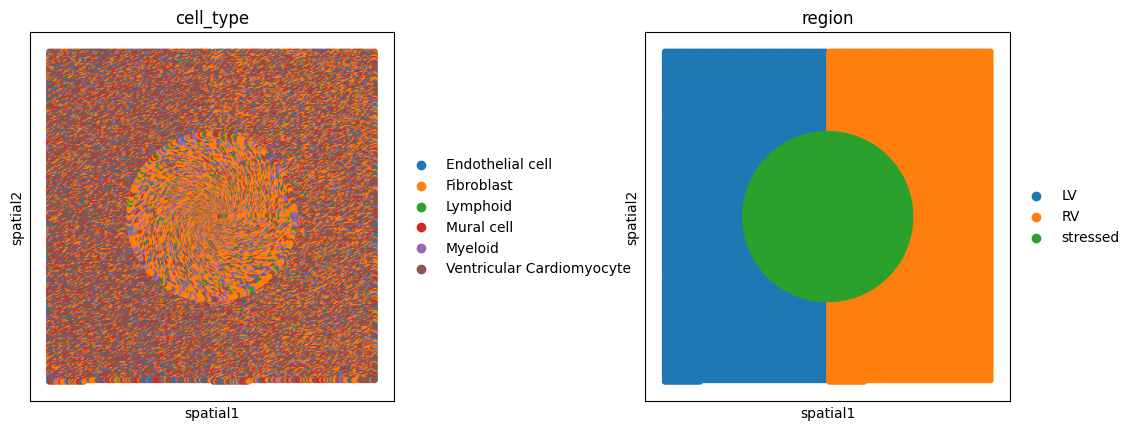

In [4]:
sc.pl.spatial(adata, color=["cell_type", 'region'], spot_size=20)

In [5]:
from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina._spatial_utils import weighted_pseudobulks, spatial_neighbors

In [6]:
n_neighbors = 20
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [7]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'].toarray()[0,:].astype(np.float32)

In [8]:
adata.var.index = adata.var['gene_name-new']

In [9]:
weighted_pseudobulks(
    adata,
    sp=adata.obsp['spatial_connectivities'],
    groupby="cell_type"
)

In [10]:
ndata = AnnData(adata.obsm['spatial_x'], obs=adata.obs, var=adata.uns['_spatial_var'], obsm=adata.obsm)

In [11]:
ndata.var['average'] = ndata.X.mean(axis=0)
ndata.var['std'] = ndata.X.std(axis=0)
ndata.var['cv'] = ndata.var['std'] / ndata.var['average']

In [12]:
ndata.var.set_index(0, inplace=True)

In [13]:
ndata.var.sort_values('cv', ascending=False, key=abs).head(5)
# TODO: need to move away from uniform representation of space

,average,std,cv
0,,,
Ventricular Cardiomyocyte_CLDN5,0.294639,0.45588,1.547252
Ventricular Cardiomyocyte_TBX1,0.294639,0.45588,1.547252
Ventricular Cardiomyocyte_IGLV6-57,0.294639,0.45588,1.547252
Ventricular Cardiomyocyte_TIAM1,0.294639,0.45588,1.547252
Ventricular Cardiomyocyte_FCGRT,0.294639,0.45588,1.547252


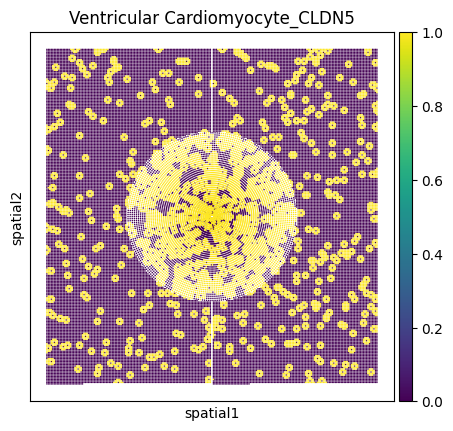

In [14]:
sc.pl.spatial(ndata, color=['Ventricular Cardiomyocyte_CLDN5'], spot_size=5)

In [15]:
adata.obsm['spatial_x'] = adata.obsm['spatial_x']

In [16]:
top_genes_idx = np.abs(np.argsort(ndata.var['cv']))[-1000:]
adata.obsm['spatial_x'] = adata.obsm['spatial_x'][:, top_genes_idx]

In [17]:
adata.obsm['spatial_x'].shape

(49800, 1000)

In [18]:
from cellina import CellinaModel

In [19]:
CellinaModel.setup_anndata(adata,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts',
                           spatial_connectivities_key='spatial_connectivities')
model = CellinaModel(adata, n_latent=20, classifier_lambda=0, discriminator_lambda=0, condition_on_intrinsic=False, link_prediction_weight=1)

INFO     Generating sequential column names                                                                        


INFO     cellina: The Cellina model has been initialized with edge prediction                                      


In [20]:
model.train(max_epochs=50,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=10,
            early_stopping_monitor='validation_loss', # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.0001,
                         'weight_decay': 0.0001,
                         'normalize_losses': False,
                        #  "scale_adversarial_loss": "normalized"
                         },
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=512,
            devices=[1]
            )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Training:   0%|          | 0/50 [00:00<?, ?it/s]

NameError: name 'z_sliced' is not defined

In [ ]:
list(model.history_.keys())

['kl_weight',
 'train_loss_step',
 'validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'vae_loss_validation',
 'classifier_loss_raw_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'fool_loss_raw_validation',
 'fool_loss_validation',
 'fool_accuracy_validation',
 'edge_prediction_loss_validation',
 'train_loss_epoch',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'vae_loss_train',
 'classifier_loss_raw_train',
 'classifier_loss_train',
 'classifier_accuracy_train',
 'fool_loss_raw_train',
 'fool_loss_train',
 'fool_accuracy_train',
 'edge_prediction_loss_train']

<Axes: xlabel='epoch'>

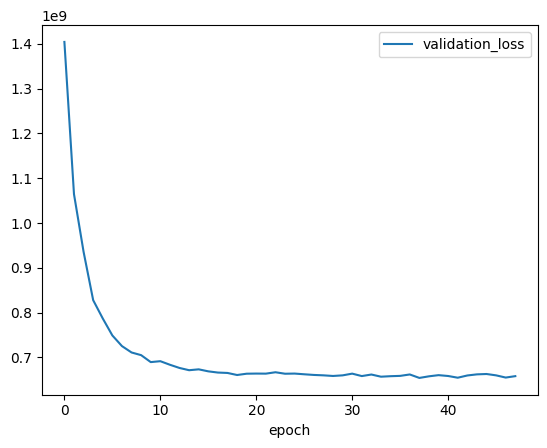

In [ ]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

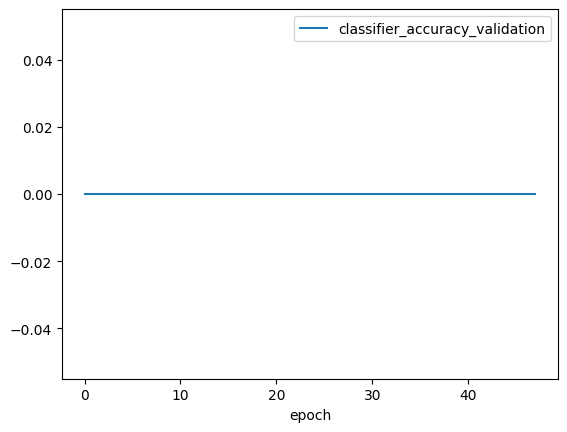

In [ ]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

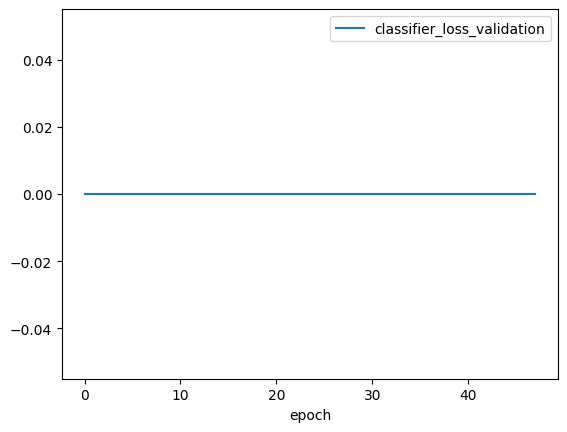

In [ ]:
model.history_['classifier_loss_validation'].plot()

<Axes: xlabel='epoch'>

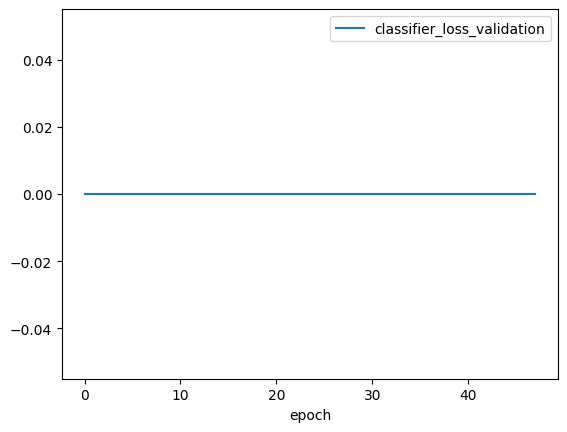

In [ ]:
model.history_['classifier_loss_validation'].plot()

In [ ]:
if 'discriminator_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['discriminator_loss_validation'].plot()

In [ ]:
model.history_.keys()

dict_keys(['kl_weight', 'train_loss_step', 'validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'train_loss_epoch', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train'])

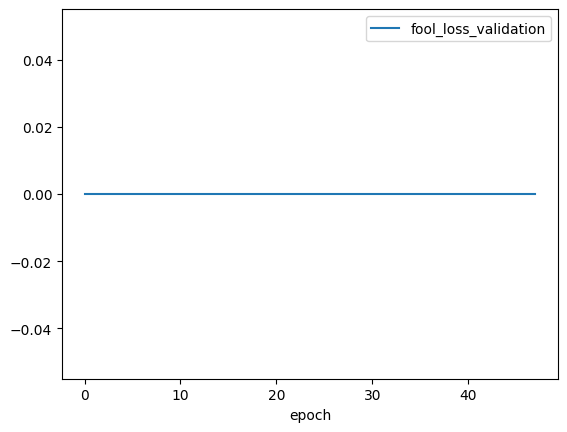

In [ ]:
if 'fool_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_validation'].plot()

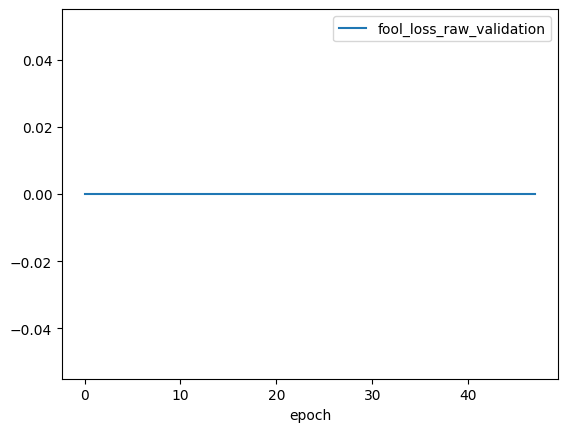

In [ ]:
if 'fool_loss_raw_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_raw_validation'].plot()

<Axes: xlabel='epoch'>

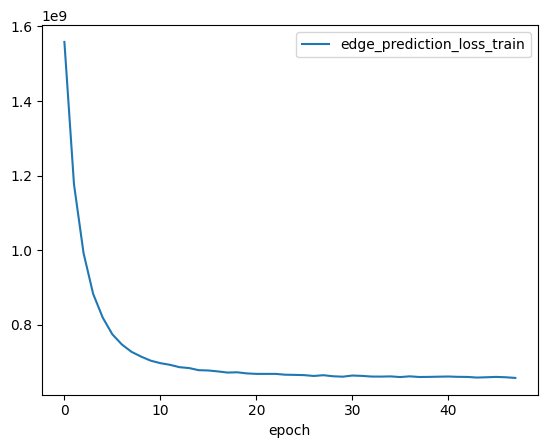

In [ ]:
model.history_['edge_prediction_loss_train'].plot()

In [ ]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

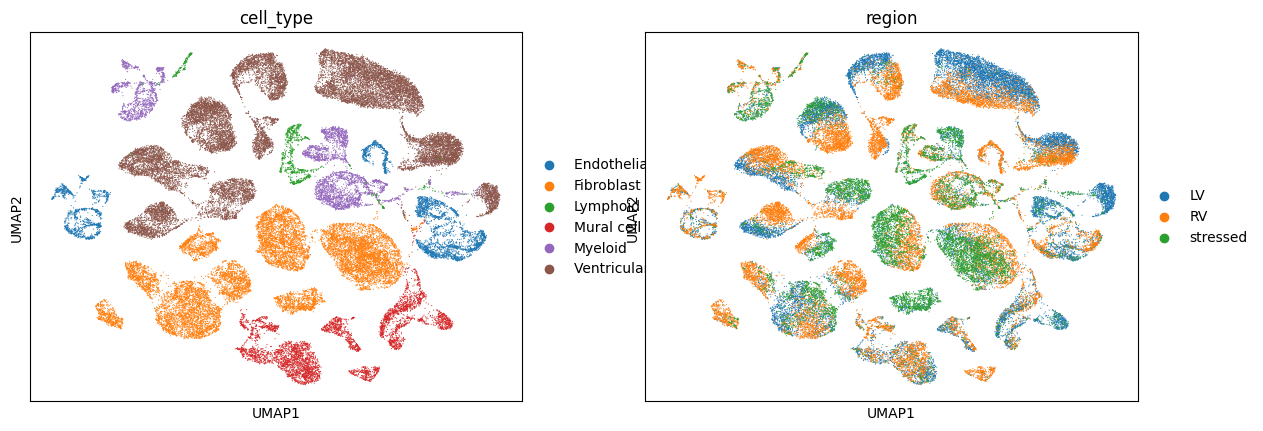

In [ ]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type', 'region'])

In [ ]:
adata.obsm['z'].max()

np.float32(6.5314736)

In [ ]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

In [ ]:
adata.obsm['s'].max()

np.float32(0.6857519)

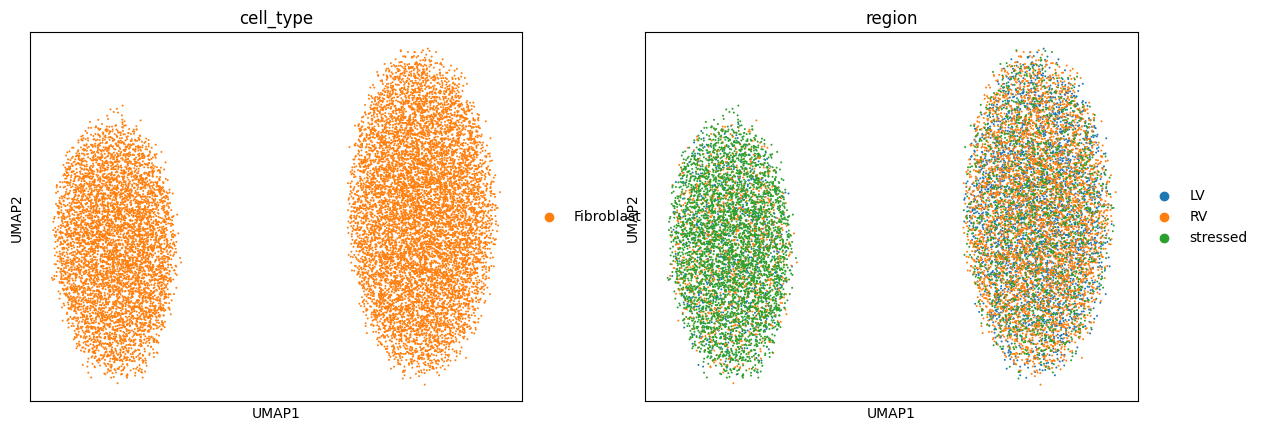

In [ ]:
fib_adata = adata[adata.obs['cell_type']=='Fibroblast']
sc.pp.neighbors(fib_adata, use_rep='s')
sc.tl.umap(fib_adata)
sc.pl.umap(fib_adata, color=['cell_type', 'region'])

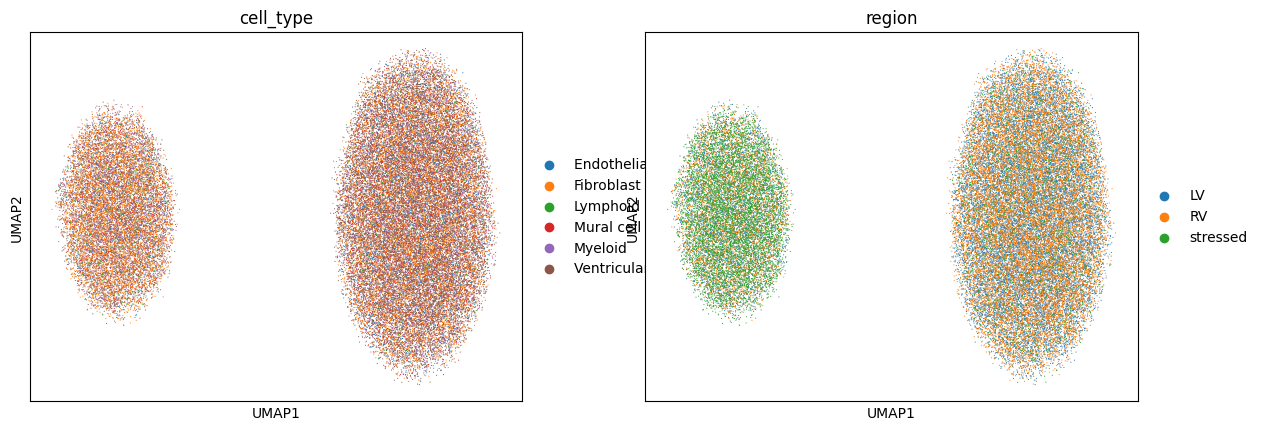

In [ ]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type', 'region'])